# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# PCA (Principal Component Analysis) - Análise de Componentes Principais


O PCA busca encontrar novas direções nos dados chamadas **componentes principais**.

Essas direções são escolhidas de modo que:

1. A primeira componente principal captura a maior variância possível dos dados.
2. A segunda componente captura a maior variância restante, sendo ortogonal à primeira.
3. As demais seguem a mesma lógica.

Em termos simples:

> O PCA encontra os eixos mais importantes de variação dos dados.

## Por que reduzir dimensionalidade?

Em aprendizado de máquina alguns datasets podem ter muitas variáveis. Algumas delas podem ser redundantes ou altamente correlacionadas.

O PCA pode ser usado para:

- reduzir a quantidade de atributos;
- visualizar dados de alta dimensão em 2D ou 3D;
- remover redundância;
- reduzir custo computacional;
- diminuir ruído em alguns casos;
- preparar dados para outros algoritmos.

Exemplo:

| Altura | Peso | IMC | Classe |
|---|---|---|---|
| 1.70 | 70 | 24.2 | A |
| 1.80 | 85 | 26.2 | B |

Algumas variáveis podem carregar informações semelhantes. O PCA tenta representar os dados em um novo sistema de coordenadas mais compacto.

## Importante: PCA é aprendizado não supervisionado

O PCA não usa o vetor de saída `y`.

Ele trabalha apenas com a matriz de entrada:

\[
X
\]

Portanto, o PCA não tenta separar classes diretamente. Ele apenas encontra direções de maior variância nos dados.

Isso significa que PCA pode ajudar na visualização de classes, mas não é um classificador.

## Exemplo com um dataset sintético



In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Variável x1
x1 = np.random.normal(0, 1, 200)

# Variável x2 fortemente correlacionada com x1
x2 = 2 * x1 + np.random.normal(0, 0.5, 200)

X = np.column_stack((x1, x2))

print(X[:5])
print("Formato de X:", X.shape)

[[ 0.49671415  1.17232199]
 [-0.1382643   0.00386366]
 [ 0.64768854  1.8369027 ]
 [ 1.52302986  3.57296074]
 [-0.23415337 -1.15714143]]
Formato de X: (200, 2)


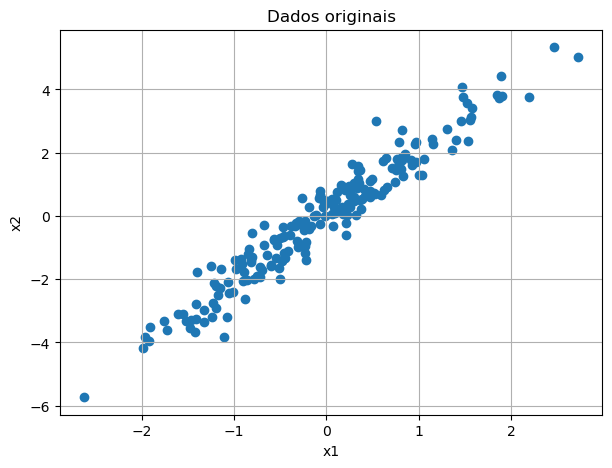

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dados originais")
plt.grid(True)
plt.show()

Os pontos estão espalhados principalmente em uma direção inclinada. Essa direção é exatamente o tipo de estrutura que o PCA tenta descobrir.

## Centralização dos dados

O primeiro passo matemático do PCA é centralizar os dados.

Cada atributo é subtraido de sua média:

$$
X_c = X - \mu
$$

onde:

$
\mu = \frac{1}{n}\sum_{i=1}^{n}x_i
$

Depois da centralização, cada variável passa a ter média zero.

Isso é necessário porque o PCA procura direções de variância ao redor da origem.

In [2]:
media = np.mean(X, axis=0)
X_c = X - media

print("Média original:", media)
print("Média após centralização:", np.mean(X_c, axis=0))

Média original: [-0.04077097 -0.03860784]
Média após centralização: [ 3.88578059e-17 -5.66213743e-17]


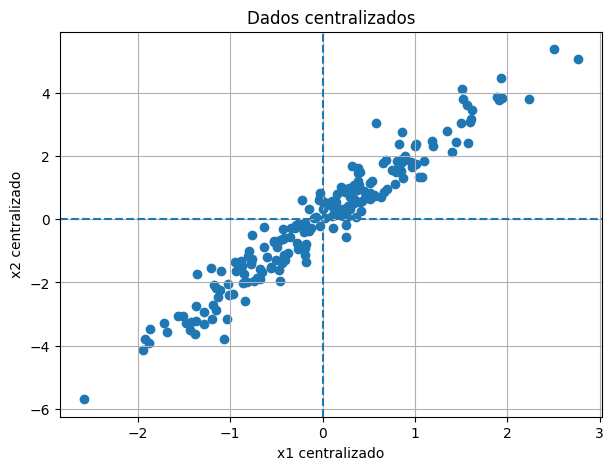

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X_c[:, 0], X_c[:, 1])
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel("x1 centralizado")
plt.ylabel("x2 centralizado")
plt.title("Dados centralizados")
plt.grid(True)
plt.show()

## Matriz de covariância

A matriz de covariância mede como as variáveis variam juntas.

Para duas variáveis \(x\) e \(y\), a covariância é:

$
\operatorname{cov}(x,y)=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$

A matriz de covariância é:

$
\Sigma = \frac{1}{n-1}X_c^T X_c
$

Para duas variáveis:

$$
\Sigma =
\begin{bmatrix}
\operatorname{var}(x_1) & \operatorname{cov}(x_1,x_2) \\
\operatorname{cov}(x_2,x_1) & \operatorname{var}(x_2)
\end{bmatrix}
$$

Se a covariância for positiva, as variáveis tendem a crescer juntas.

In [4]:
cov_matrix = np.cov(X_c, rowvar=False)

print("Matriz de covariância:")
print(cov_matrix)

Matriz de covariância:
[[0.86676829 1.77725193]
 [1.77725193 3.8854787 ]]


## Autovalores e Autovetores

O PCA usa autovalores e autovetores da matriz de covariância.

A equação fundamental é:

$$
\Sigma v = \lambda v
$$

onde:

- ($\Sigma$) é a matriz de covariância;
- ($v$) é um autovetor;
- ($\lambda$) é um autovalor.

Interpretação:

- O **autovetor** indica uma direção principal dos dados.
- O **autovalor** indica quanta variância existe naquela direção.

A maior componente principal é o autovetor associado ao maior autovalor.

In [5]:
autovalores, autovetores = np.linalg.eig(cov_matrix)

print("Autovalores:")
print(autovalores)

print("\nAutovetores:")
print(autovetores)

Autovalores:
[0.04443364 4.70781335]

Autovetores:
[[-0.90755784 -0.4199271 ]
 [ 0.4199271  -0.90755784]]


## Ordenando as Componentes Principais

Os autovalores indicam a importância de cada componente.

Os autovalores devem ser ordenados do maior para o menor e reorganizar os autovetores na mesma ordem.

In [6]:
indices = np.argsort(autovalores)[::-1]

autovalores_ordenados = autovalores[indices]
autovetores_ordenados = autovetores[:, indices]

print("Autovalores ordenados:")
print(autovalores_ordenados)

print("\nAutovetores ordenados:")
print(autovetores_ordenados)

Autovalores ordenados:
[4.70781335 0.04443364]

Autovetores ordenados:
[[-0.4199271  -0.90755784]
 [-0.90755784  0.4199271 ]]


## Variância Explicada

A variância explicada mostra quanto da informação dos dados é capturada por cada componente principal.

$$
\text{variância explicada}_i = \frac{\lambda_i}{\sum_j \lambda_j}
$$

Se a primeira componente explica, por exemplo, 95% da variância, significa que quase toda a estrutura dos dados pode ser representada em apenas uma dimensão.

In [8]:
variancia_explicada = autovalores_ordenados / np.sum(autovalores_ordenados)

print("Variância explicada:")
print(variancia_explicada)

print("\nVariância explicada acumulada:")
print(np.cumsum(variancia_explicada))

Variância explicada:
[0.99064997 0.00935003]

Variância explicada acumulada:
[0.99064997 1.        ]


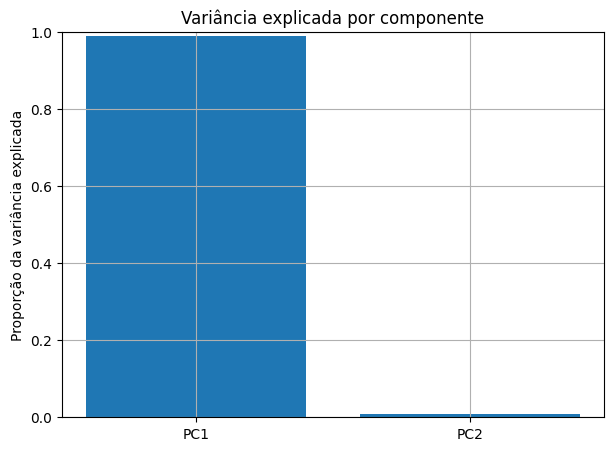

In [9]:
plt.figure(figsize=(7, 5))
plt.bar([1, 2], variancia_explicada)
plt.xticks([1, 2], ["PC1", "PC2"])
plt.ylabel("Proporção da variância explicada")
plt.title("Variância explicada por componente")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

## Visualização dos Autovetores

Agora vamos desenhar as direções principais sobre os dados.

A primeira direção deve acompanhar o maior espalhamento da nuvem de pontos.

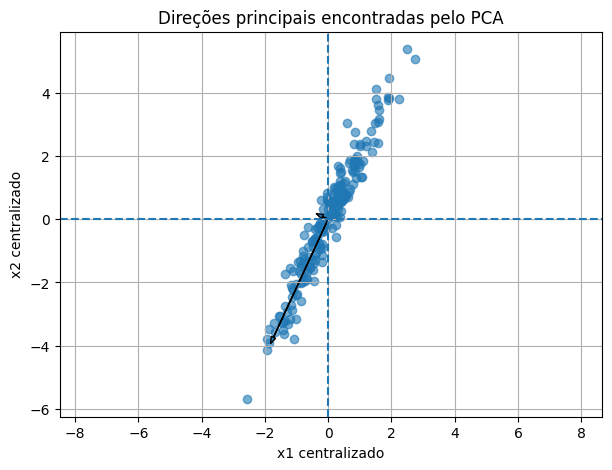

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(X_c[:, 0], X_c[:, 1], alpha=0.6)

origem = np.array([0, 0])

for i in range(2):
    vetor = autovetores_ordenados[:, i] * np.sqrt(autovalores_ordenados[i]) * 2
    plt.arrow(
        origem[0], origem[1],
        vetor[0], vetor[1],
        head_width=0.15,
        length_includes_head=True
    )

plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel("x1 centralizado")
plt.ylabel("x2 centralizado")
plt.title("Direções principais encontradas pelo PCA")
plt.grid(True)
plt.axis('equal')
plt.show()

## Projetando os Dados

Depois de encontrar as componentes principais, projeta-se os dados nesse novo sistema de coordenadas.

Para reduzir de 2 dimensões para 1 dimensão, é utilizado apenas o primeiro autovetor:

$$
Z = X_c W
$$

onde:

- ($X_c$) é a matriz centralizada;
- ($W$) é a matriz com os autovetores escolhidos;
- ($Z$) é a nova representação dos dados.

Essa etapa é a redução de dimensionalidade propriamente dita.

In [11]:
# Mantendo apenas a primeira componente principal
W = autovetores_ordenados[:, :1]

Z = X_c @ W

print("Formato original:", X.shape)
print("Formato após PCA:", Z.shape)
print(Z[:5])

Formato original: (200, 2)
Formato após PCA: (200, 1)
[[-1.32469342e+00]
 [ 2.39475344e-03]
 [-1.99123709e+00]
 [-3.93438971e+00]
 [ 1.09634045e+00]]


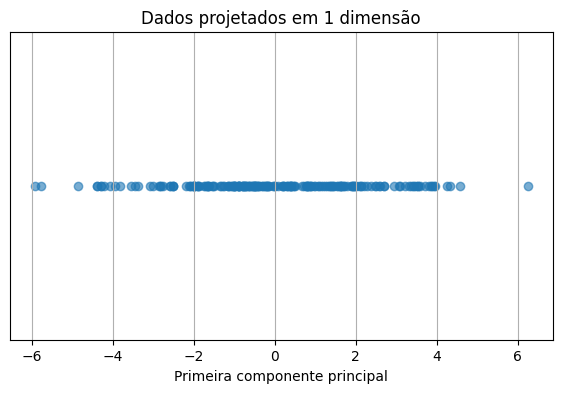

In [12]:
plt.figure(figsize=(7, 4))
plt.scatter(Z[:, 0], np.zeros_like(Z[:, 0]), alpha=0.6)
plt.xlabel("Primeira componente principal")
plt.yticks([])
plt.title("Dados projetados em 1 dimensão")
plt.grid(True)
plt.show()

## Reconstruindo os Dados Aproximados

É possível projetar os dados de volta para o espaço original, mas com uma aproximação.

$$
\hat{X} = ZW^T + \mu
$$

Como foi utilizado apenas uma componente, parte da informação foi perdida.

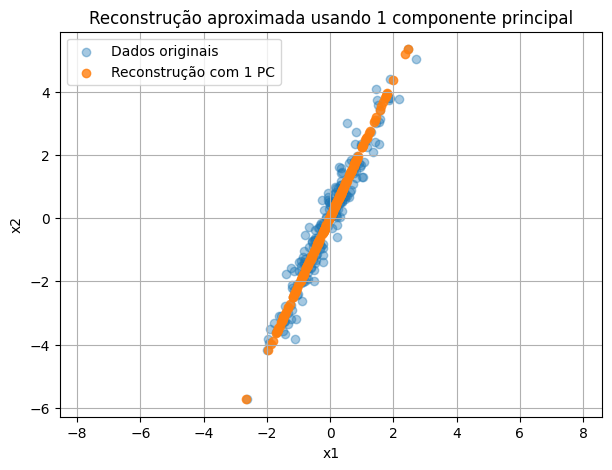

In [13]:
X_reconstruido = Z @ W.T + media

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.4, label="Dados originais")
plt.scatter(X_reconstruido[:, 0], X_reconstruido[:, 1], alpha=0.8, label="Reconstrução com 1 PC")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Reconstrução aproximada usando 1 componente principal")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## PCA do scikit-learn



In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
Z_sklearn = pca.fit_transform(X)

print("Componentes principais do sklearn:")
print(pca.components_)

print("\nVariância explicada:")
print(pca.explained_variance_ratio_)

print("\nFormato após PCA:", Z_sklearn.shape)

Componentes principais do sklearn:
[[0.4199271  0.90755784]]

Variância explicada:
[0.99064997]

Formato após PCA: (200, 1)


A direção pode aparecer com sinal invertido em relação à implementação manual.

Isso não é erro.

Em Álgebra Linear, se \(v\) é autovetor, então \(-v\) também é autovetor.

A direção geométrica é a mesma.

## Exemplo: PCA com dataset Iris

O dataset Iris possui 4 atributos:

- comprimento da sépala;
- largura da sépala;
- comprimento da pétala;
- largura da pétala.

O objetivo é aplicar o PCA para reduzir para 2 componentes principais para visualizar os dados em 2D.

In [15]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
nomes_classes = iris.target_names

print("Formato original:", X_iris.shape)
print("Atributos:", iris.feature_names)

Formato original: (150, 4)
Atributos: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## Padronização dos Dados

O PCA é sensível à escala, pois usa variâncias.

Se uma variável tiver escala muito maior que as outras, ela pode dominar as componentes principais.

A padronização dos dados é fundamental para se utilizar o PCA.

$$
z = \frac{x - \mu}{\sigma}
$$



In [16]:
scaler = StandardScaler()
X_iris_pad = scaler.fit_transform(X_iris)

print("Média após padronização:")
print(np.mean(X_iris_pad, axis=0))

print("\nDesvio padrão após padronização:")
print(np.std(X_iris_pad, axis=0))

Média após padronização:
[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]

Desvio padrão após padronização:
[1. 1. 1. 1.]


In [17]:
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_pad)

print("Formato após PCA:", X_iris_pca.shape)
print("Variância explicada:", pca_iris.explained_variance_ratio_)
print("Variância acumulada:", np.sum(pca_iris.explained_variance_ratio_))

Formato após PCA: (150, 2)
Variância explicada: [0.72962445 0.22850762]
Variância acumulada: 0.9581320720000166


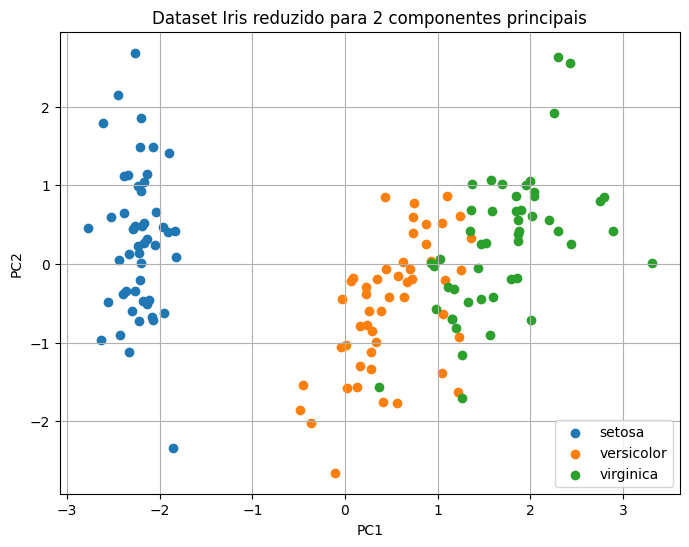

In [18]:
plt.figure(figsize=(8, 6))

for classe in np.unique(y_iris):
    plt.scatter(
        X_iris_pca[y_iris == classe, 0],
        X_iris_pca[y_iris == classe, 1],
        label=nomes_classes[classe]
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Dataset Iris reduzido para 2 componentes principais")
plt.legend()
plt.grid(True)
plt.show()

## Variância Explicada Acumulada

Em problemas reais, o número de componentes é escolhido com base na analise da variância explicada acumulada.

Por exemplo, pode-se escolher o menor número de componentes que explique 90%, 95% ou 99% da variância.

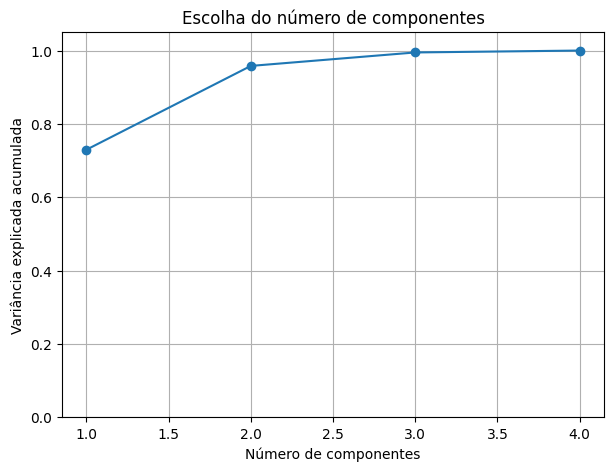

Variância acumulada:
[0.72962445 0.95813207 0.99482129 1.        ]


In [19]:
pca_total = PCA()
pca_total.fit(X_iris_pad)

variancia_acumulada = np.cumsum(pca_total.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o')
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("Escolha do número de componentes")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

print("Variância acumulada:")
print(variancia_acumulada)

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.